In [18]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [19]:
DATASET = Path("../backend/app/datasets/matching_dataset.csv")

df = pd.read_csv(DATASET)

print(df.shape)

df.head()

(3304, 28)


,resume_name,job_id,company,title,matched_skill_count,missing_skill_count,resume_skill_count,job_skill_count,skill_overlap_ratio,experience_gap,...,overall_score,confidence,recommendation,matched_skills,missing_skills,retrieval_score,title_similarity,keyword_similarity,technical_job_score,label
0,28320387.pdf,2826285517,Butler University,"Assistant Director of Admission, Midwest Regio...",3,10,5,13,0.2308,1,...,26.92,Low,Not Recommended,"Communication, Make, Leadership","Amazon Neptune, Automated Testing, iOS SDK, HI...",0.2437,0.0,0.0276,8.0,0
1,14206561.pdf,56924323,NaN,Structural Engineer,1,4,1,5,0.2000,0,...,46.00,Low,Not Recommended,Excel,"Retrofit, Amazon Neptune, Automated Testing, i...",0.3605,0.0,0.0094,20.0,1
2,15941675.pdf,3045980831,Armstrong Builders LLC,Project Engineer,1,3,5,4,0.2500,0,...,46.25,Low,Not Recommended,Communication,"Mobile Security, Automated Testing, Attention ...",0.3758,0.0,0.0156,28.0,1
3,28628090.pdf,121605673,NaN,Licensed Acupuncturist,2,6,14,8,0.2500,0,...,48.75,Low,Not Recommended,"Communication, D","Reverse Engineering, Amazon Neptune, iOS SDK, ...",0.4129,0.0,0.0075,0.0,1
4,13264796.pdf,2147609929,The Job Network,Production Planner,0,11,11,11,0.0000,0,...,35.91,Low,Not Recommended,NaN,"Mobile Security, Amazon Neptune, Automated Tes...",0.3140,0.0,0.0070,8.0,0


In [20]:
FEATURES = [

    "matched_skill_count",

    "missing_skill_count",

    "resume_skill_count",

    "job_skill_count",

    "skill_overlap_ratio",

    "experience_gap",

    "education_gap",

    "project_match_count",

    "certification_match_count",

    "skill_score",

    "education_score",

    "experience_score",

    "project_score",

    "certification_score",

    "retrieval_score",

    "title_similarity",

    "keyword_similarity"

]

TARGET = "label"

X = df[FEATURES]

y = df[TARGET]

print(X.shape)

print(y.shape)

(3304, 17)
(3304,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    stratify=y,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(2643, 17)
(661, 17)


In [22]:
# from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [23]:
model.fit(

    X_train,

    y_train

)

print("Training Completed")

Training Completed


In [24]:
pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

In [25]:
accuracy = accuracy_score(y_test,pred)

precision = precision_score(y_test,pred)

recall = recall_score(y_test,pred)

f1 = f1_score(y_test,pred)

auc = roc_auc_score(y_test,prob)

print("="*60)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC AUC  : {auc:.4f}")

print("="*60)

Accuracy : 0.9985
Precision: 1.0000
Recall   : 0.9970
F1 Score : 0.9985
ROC AUC  : 0.9999


In [26]:
print(

    classification_report(

        y_test,

        pred

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      1.00      1.00       330

    accuracy                           1.00       661
   macro avg       1.00      1.00      1.00       661
weighted avg       1.00      1.00      1.00       661



In [27]:
cm = confusion_matrix(

    y_test,

    pred

)

print(cm)

[[331   0]
 [  1 329]]


In [28]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

scores = cross_val_score(

    model,

    X,

    y,

    cv=cv,

    scoring="accuracy"

)

print(scores)

print()

print("Average Accuracy")

print(scores.mean())

[1.         0.99848714 0.99848714 1.         0.99848485]

Average Accuracy
0.9990918259753357


In [29]:
importance = pd.DataFrame({

    "Feature":FEATURES,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance

,Feature,Importance
9,skill_score,0.484994
4,skill_overlap_ratio,0.264542
11,experience_score,0.085602
10,education_score,0.071142
5,experience_gap,0.033908
14,retrieval_score,0.022499
6,education_gap,0.012217
0,matched_skill_count,0.010166
3,job_skill_count,0.002891
1,missing_skill_count,0.002669


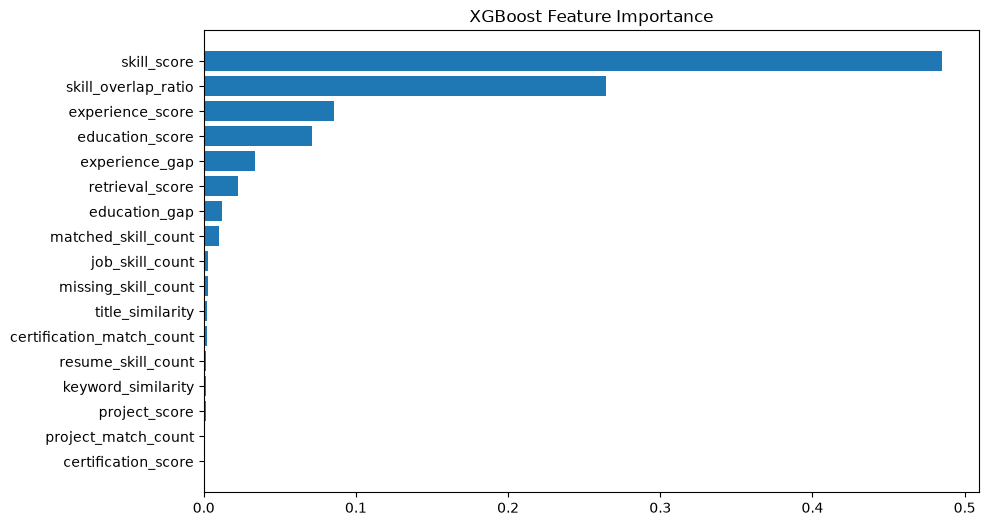

In [30]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [31]:
MODEL_DIR = Path("../backend/app/models")

MODEL_DIR.mkdir(

    parents=True,

    exist_ok=True

)

joblib.dump(

    model,

    MODEL_DIR/"xgboost_model.pkl"

)

joblib.dump(

    FEATURES,

    MODEL_DIR/"feature_columns.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [32]:
loaded = joblib.load(

    MODEL_DIR/"xgboost_model.pkl"

)

print(type(loaded))

<class 'xgboost.sklearn.XGBClassifier'>
